SESSION 7 - Regression Model EvaluationTopics Covered:Evaluation metrics:MSE (Mean Squared Error)RMSEMAER² scoreResidual plotsInterpreting errorsOverfitting detection via evaluation metricsHands-on:Comparing models using metrics
Pending
Tasks
1.
Given two arrays: one with actual delivery times and one with predicted delivery times for 10 Zomato orders, calculate the Mean Squared Error (MSE) and Root Mean Squared Error (RMSE) using Python.
2.
For a Flipkart product price prediction task, you have arrays of actual prices and predicted prices. Write a function to compute the Mean Absolute Error (MAE) and R² score, and print both values.<br><br><em><strong>Hint:</strong> Use sklearn.metrics.mean_absolute_error and sklearn.metrics.r2_score.</em>
3.
Create a residual plot for a dataset of actual vs predicted movie ratings (scale 1-5) for 20 movies, using matplotlib. Label the axes and briefly describe what the plot tells you about your model's errors.
4.
You have two models predicting the delivery time for Swiggy orders. Model A has an RMSE of 8 minutes and R² of 0.65, Model B has an RMSE of 6 minutes and R² of 0.55. Which model would you choose and why? Explain your reasoning based on the evaluation metrics.
5.
Compare two regression models for predicting Spotify song popularity: calculate MSE, RMSE, MAE, and R² for both models using sklearn, then identify which model is likely overfitting based on the results.<br><br><em><strong>Hint:</strong> Overfitting often shows very low error on training data but much higher error on test data.</em>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split

In [2]:
# TASK 1: Zomato Delivery Times (MSE & RMSE)
# Actual vs Predicted delivery times (in minutes) for 10 orders
zomato_actual = np.array([25, 30, 18, 40, 35, 22, 28, 45, 32, 20])
zomato_pred = np.array([23, 34, 20, 37, 32, 25, 29, 41, 36, 18])

mse_zomato = mean_squared_error(zomato_actual, zomato_pred)
rmse_zomato = np.sqrt(mse_zomato)

print(f"Mean Squared Error (MSE): {mse_zomato:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_zomato:.2f} minutes\n")

Mean Squared Error (MSE): 8.80
Root Mean Squared Error (RMSE): 2.97 minutes



In [3]:
# TASK 2: Flipkart Product Price Prediction (MAE & R² Function)
flipkart_actual = np.array([499, 1299, 899, 2499, 1500, 350, 999])
flipkart_pred = np.array([450, 1350, 820, 2300, 1590, 380, 1020])

def evaluate_predictions(actual, predicted):
    mae = mean_absolute_error(actual, predicted)
    r2 = r2_score(actual, predicted)
    print(f"Mean Absolute Error (MAE): ₹{mae:.2f}")
    print(f"R² Score (Coefficient of Determination): {r2:.4f}\n")

evaluate_predictions(flipkart_actual, flipkart_pred)

Mean Absolute Error (MAE): ₹74.14
R² Score (Coefficient of Determination): 0.9806



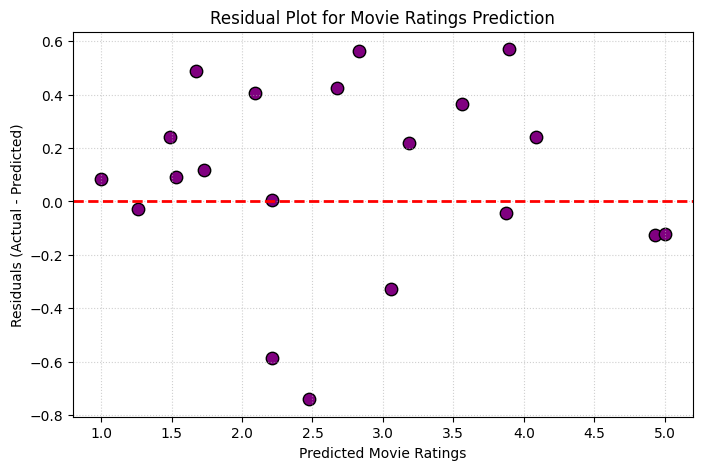

In [4]:
# TASK 3: Movie Ratings Residual Plot
# 20 Movie ratings (Scale 1-5)
np.random.seed(42)
movie_actual = np.random.uniform(1.0, 5.0, 20)
# Add random error to generate predictions
movie_pred = movie_actual + np.random.normal(0, 0.4, 20)
movie_pred = np.clip(movie_pred, 1.0, 5.0) # Ensure scale constraints

# Calculate Residuals (Actual - Predicted)
residuals = movie_actual - movie_pred

plt.figure(figsize=(8, 5))
plt.scatter(movie_pred, residuals, color='purple', edgecolor='k', s=80)
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)
plt.title('Residual Plot for Movie Ratings Prediction')
plt.xlabel('Predicted Movie Ratings')
plt.ylabel('Residuals (Actual - Predicted)')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

In [7]:
# TASK 5: Spotify Song Popularity Overfitting Detection
# Load the generated Spotify dataset
df = pd.read_csv('spotify_song_popularity.csv')

X = df[['Tempo', 'Danceability', 'Energy']]
y = df['Popularity']

# Split into Train and Test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- MODEL A: Balanced Linear Regression Model ---
model_A = LinearRegression()
model_A.fit(X_train, y_train)

train_pred_A = model_A.predict(X_train)
test_pred_A = model_A.predict(X_test)

# --- MODEL B: Complex Overfitted Polynomial Model ---
poly = PolynomialFeatures(degree=5) # High degree introduces heavy overfitting
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

model_B = LinearRegression()
model_B.fit(X_train_poly, y_train)

train_pred_B = model_B.predict(X_train_poly)
test_pred_B = model_B.predict(X_test_poly)

# Evaluation Helper
def print_metrics(model_name, y_true_train, y_pred_train, y_true_test, y_pred_test):
    print(f"[{model_name}]")
    print(f"  Train -> MSE: {mean_squared_error(y_true_train, y_pred_train):.2f} | RMSE: {np.sqrt(mean_squared_error(y_true_train, y_pred_train)):.2f} | MAE: {mean_absolute_error(y_true_train, y_pred_train):.2f} | R²: {r2_score(y_true_train, y_pred_train):.4f}")
    print(f"  Test  -> MSE: {mean_squared_error(y_true_test, y_pred_test):.2f} | RMSE: {np.sqrt(mean_squared_error(y_true_test, y_pred_test)):.2f} | MAE: {mean_absolute_error(y_true_test, y_pred_test):.2f} | R²: {r2_score(y_true_test, y_pred_test):.4f}\n")

print_metrics("Model A (Simple Linear)", y_train, train_pred_A, y_test, test_pred_A)
print_metrics("Model B (High-Degree Polynomial)", y_train, train_pred_B, y_test, test_pred_B)

[Model A (Simple Linear)]
  Train -> MSE: 24.55 | RMSE: 4.95 | MAE: 3.63 | R²: 0.6691
  Test  -> MSE: 22.53 | RMSE: 4.75 | MAE: 3.76 | R²: 0.7240

[Model B (High-Degree Polynomial)]
  Train -> MSE: 8.91 | RMSE: 2.98 | MAE: 2.14 | R²: 0.8800
  Test  -> MSE: 102.22 | RMSE: 10.11 | MAE: 7.45 | R²: -0.2527

